<div align="center">

### Name: Andrew Ryu
### <span style ="color:#8C1515;"> Stanford Pre-Collegiate Summer Institutes (Intro to Machine Learning) </span>

</div>

### Project Title: MAGIC Gamma Telescope Prediction

### Dataset Link: https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope

### Description of Dataset:
"The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamma telescope observes high energy gamma rays, taking advantage of the radiation emitted by charged particles produced inside the electromagnetic showers initiated by the gammas, and developing in the atmosphere. This Cherenkov radiation (of visible to UV wavelengths) leaks through the atmosphere and gets recorded in the detector, allowing reconstruction of the shower parameters. The available information consists of pulses left by the incoming Cherenkov photons on the photomultiplier tubes, arranged in a plane, the camera. Depending on the energy of the primary gamma, a total of few hundreds to some 10000 Cherenkov photons get collected, in patterns (called the shower image), allowing to discriminate statistically those caused by primary gammas (signal) from the images of hadronic showers initiated by cosmic rays in the upper atmosphere (background). Typically, the image of a shower after some pre-processing is an elongated cluster. Its long axis is oriented towards the camera center if the shower axis is parallel to the telescope's optical axis, i.e. if the telescope axis is directed towards a point source. A principal component analysis is performed in the camera plane, which results in a correlation axis and defines an ellipse. If the depositions were distributed as a bivariate Gaussian, this would be an equidensity ellipse. The characteristic parameters of this ellipse (often called Hillas parameters) are among the image parameters that can be used for discrimination. The energy depositions are typically asymmetric along the major axis, and this asymmetry can also be used in discrimination. There are, in addition, further discriminating characteristics, like the extent of the cluster in the image plane, or the total sum of depositions."

**Number of Instances:** 19020

**Independent Variables:**
* fLength: major axis of ellipse in millimeters
* fWidth: minor axis of ellipse in millimeters
* fSize: 10-log of sum of content of all pixels
* fConc: ratio of sum of two highest pixels over fSize
* fConc1: ratio of highest pixel over fSize
* fAsym: distance from highest pixel to center, projected onto major axis
* fM3Long: 3rd root of third moment along major axis
* fM3Trans: 3rd root of third moment along minor axis
* fAlpha: angle of major axis with vector to origin
* fDist: distance from origin to center of ellipse

**Dependent Variables:**
* Outcome: whether the reading was from a primary gamma or a hadronic shower





In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
from scipy.stats import skew, norm, probplot
from matplotlib.pyplot import boxplot
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import 
column_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist',
    'outcome']
df = pd.read_csv("magic04.data", header = None, names = column_names)

# For .data files, use:      df = p.read_csv(("file_name.data", header="None")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  outcome   19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


In [4]:
df["outcome"] = df["outcome"].map({"h": 0, "g": 1})

In [5]:
df.head(10)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1
5,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.0980,1
6,48.2468,17.3565,3.0332,0.2529,0.1515,8.5730,38.0957,10.5868,4.7920,219.0870,1
7,26.7897,13.7595,2.5521,0.4236,0.2174,29.6339,20.4560,-2.9292,0.8120,237.1340,1
8,96.2327,46.5165,4.1540,0.0779,0.0390,110.3550,85.0486,43.1844,4.8540,248.2260,1
9,46.7619,15.1993,2.5786,0.3377,0.1913,24.7548,43.8771,-6.6812,7.8750,102.2510,1


In [6]:
df.tail(10)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
19010,32.4902,10.6723,2.4742,0.4664,0.2735,-27.0097,-21.1687,8.4813,69.1730,120.6680,0
19011,79.5528,44.9929,3.5488,0.1656,0.0900,-39.6213,53.7866,-30.0054,15.8075,311.5680,0
19012,31.8373,13.8734,2.8251,0.4169,0.1988,-16.4919,-27.1448,11.1098,11.3663,100.0566,0
19013,182.5003,76.5568,3.6872,0.1123,0.0666,192.2675,93.0302,-62.6192,82.1691,283.4731,0
19014,43.2980,17.3545,2.8307,0.2877,0.1646,-60.1842,-33.8513,-3.6545,78.4099,224.8299,0
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174,0


In [7]:
df.mean()

fLength      53.250154
fWidth       22.180966
fSize         2.825017
fConc         0.380327
fConc1        0.214657
fAsym        -4.331745
fM3Long      10.545545
fM3Trans      0.249726
fAlpha       27.645707
fDist       193.818026
outcome       0.648370
dtype: float64

In [8]:
df.median()

fLength      37.14770
fWidth       17.13990
fSize         2.73960
fConc         0.35415
fConc1        0.19650
fAsym         4.01305
fM3Long      15.31410
fM3Trans      0.66620
fAlpha       17.67950
fDist       191.85145
outcome       1.00000
dtype: float64

In [9]:
df.mode()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
0,12.9176,0.0,2.1508,0.6,0.194,0.0,0.0,0.0,0.0002,100.395,1.0
1,19.1572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.737,NaN
2,20.7522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146.354,NaN
3,24.8332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.372,NaN
4,26.9187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,159.840,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168.774,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182.013,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.909,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.927,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186.828,NaN


In [10]:
df.std()*3

fLength     127.094565
fWidth       55.038169
fSize         1.417796
fConc         0.548439
fConc1        0.331532
fAsym       177.618186
fM3Long     153.000354
fM3Trans     62.482317
fAlpha       78.310862
fDist       224.195361
outcome       1.432475
dtype: float64

In [11]:
df.columns

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist', 'outcome'],
      dtype='object')

In [12]:
# Number of rows, columns
df.shape

(19020, 11)

In [13]:
df.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026,0.648370
std,42.364855,18.346056,0.472599,0.182813,0.110511,59.206062,51.000118,20.827439,26.103621,74.731787,0.477492
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600,0.000000
25%,24.336000,11.863800,2.477100,0.235800,0.128475,-20.586550,-12.842775,-10.849375,5.547925,142.492250,0.000000
50%,37.147700,17.139900,2.739600,0.354150,0.196500,4.013050,15.314100,0.666200,17.679500,191.851450,1.000000
75%,70.122175,24.739475,3.101600,0.503700,0.285225,24.063700,35.837800,10.946425,45.883550,240.563825,1.000000
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000,1.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


In [15]:
# Reduce number of decimals
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,19020.000,53.250,42.365,4.284,24.336,37.148,70.122,334.177
fWidth,19020.000,22.181,18.346,0.000,11.864,17.140,24.739,256.382
fSize,19020.000,2.825,0.473,1.941,2.477,2.740,3.102,5.323
fConc,19020.000,0.380,0.183,0.013,0.236,0.354,0.504,0.893
fConc1,19020.000,0.215,0.111,0.000,0.128,0.197,0.285,0.675
fAsym,19020.000,-4.332,59.206,-457.916,-20.587,4.013,24.064,575.241
fM3Long,19020.000,10.546,51.000,-331.780,-12.843,15.314,35.838,238.321
fM3Trans,19020.000,0.250,20.827,-205.895,-10.849,0.666,10.946,179.851
fAlpha,19020.000,27.646,26.104,0.000,5.548,17.679,45.884,90.000
fDist,19020.000,193.818,74.732,1.283,142.492,191.851,240.564,495.561


In [16]:
df["outcome"].value_counts() # also can use df.outcome.value_counts()

outcome
1    12332
0     6688
Name: count, dtype: int64

In [17]:
np.random.seed() # putting a number in the parameters generates a repeating random sequence
df.sample(n=15)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
10369,49.121,15.037,2.669,0.375,0.192,12.361,27.579,-6.552,1.136,194.653,1
11529,62.345,32.063,3.553,0.152,0.082,40.717,63.985,20.234,7.610,176.991,1
18936,111.436,43.329,3.530,0.164,0.084,-97.500,-38.826,36.874,10.884,341.008,0
13757,17.793,11.619,2.514,0.600,0.436,-0.046,-8.097,11.183,40.877,221.105,0
3035,20.659,14.661,2.572,0.544,0.344,21.344,17.062,-7.643,18.318,246.402,1
2409,25.282,19.674,2.702,0.405,0.220,8.906,-17.340,15.547,0.683,234.623,1
9592,49.724,16.877,2.878,0.261,0.133,53.172,21.472,-15.678,2.233,211.993,1
13143,14.168,12.264,2.412,0.582,0.386,14.544,16.866,-15.414,23.019,221.536,0
13555,21.797,15.717,2.623,0.391,0.249,27.252,23.665,5.518,69.323,138.703,0
9480,56.056,14.940,2.763,0.347,0.196,54.836,43.936,12.678,15.373,234.783,1


In [18]:
df[df.duplicated()].count()

fLength     115
fWidth      115
fSize       115
fConc       115
fConc1      115
fAsym       115
fM3Long     115
fM3Trans    115
fAlpha      115
fDist       115
outcome     115
dtype: int64

In [19]:
NaN = np.nan
df["New_Column"] = NaN

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fLength     19020 non-null  float64
 1   fWidth      19020 non-null  float64
 2   fSize       19020 non-null  float64
 3   fConc       19020 non-null  float64
 4   fConc1      19020 non-null  float64
 5   fAsym       19020 non-null  float64
 6   fM3Long     19020 non-null  float64
 7   fM3Trans    19020 non-null  float64
 8   fAlpha      19020 non-null  float64
 9   fDist       19020 non-null  float64
 10  outcome     19020 non-null  int64  
 11  New_Column  0 non-null      float64
dtypes: float64(11), int64(1)
memory usage: 1.7 MB


In [21]:
del df['New_Column']

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  outcome   19020 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.6 MB


## Exploratory Data Analysis

In [23]:
# Pearson's Correlation
df.corr()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
fLength,1.000,0.771,0.702,-0.631,-0.598,-0.369,-0.120,0.013,-0.009,0.418,-0.308
fWidth,0.771,1.000,0.718,-0.610,-0.581,-0.267,-0.176,0.040,0.066,0.337,-0.266
fSize,0.702,0.718,1.000,-0.851,-0.809,-0.160,0.095,0.015,-0.187,0.437,-0.118
fConc,-0.631,-0.610,-0.851,1.000,0.976,0.112,-0.122,-0.011,0.235,-0.328,0.025
fConc1,-0.598,-0.581,-0.809,0.976,1.000,0.100,-0.119,-0.011,0.230,-0.305,0.005
fAsym,-0.369,-0.267,-0.160,0.112,0.100,1.000,0.274,0.003,-0.056,-0.207,0.174
fM3Long,-0.120,-0.176,0.095,-0.122,-0.119,0.274,1.000,-0.017,-0.186,0.037,0.193
fM3Trans,0.013,0.040,0.015,-0.011,-0.011,0.003,-0.017,1.000,0.005,0.011,-0.004
fAlpha,-0.009,0.066,-0.187,0.235,0.230,-0.056,-0.186,0.005,1.000,-0.221,-0.461
fDist,0.418,0.337,0.437,-0.328,-0.305,-0.207,0.037,0.011,-0.221,1.000,-0.065


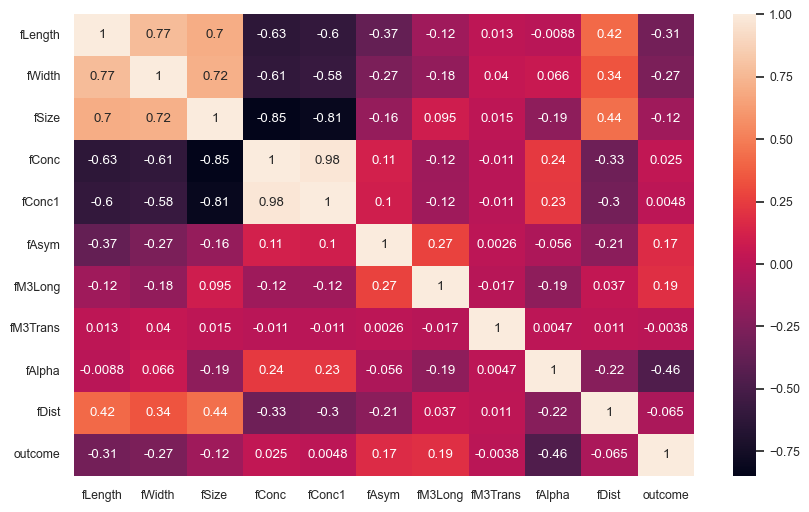

In [24]:
# Pearson's Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(), annot=True);
plt.show();

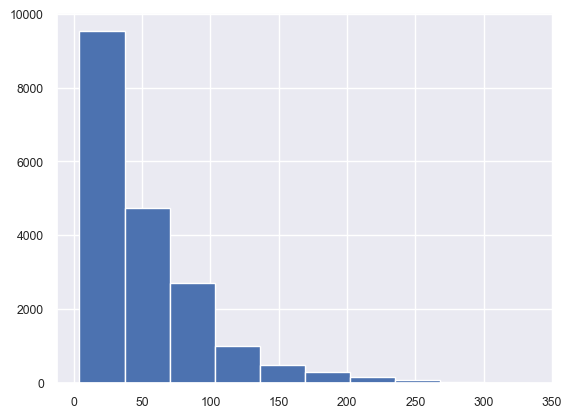

In [25]:
plt.hist(df["fLength"], color='b');
plt.show();

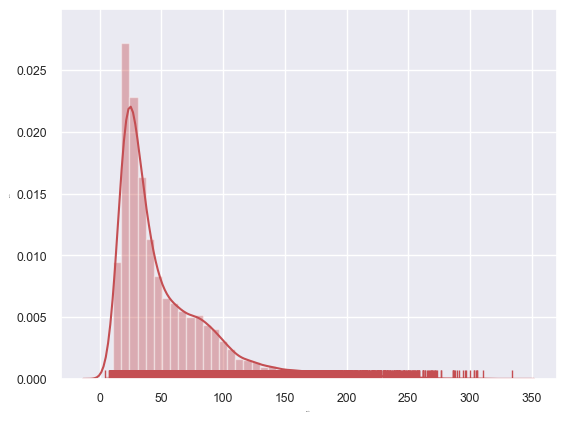

In [26]:
sns.distplot(df["fLength"], color='r', rug=True);
plt.show();

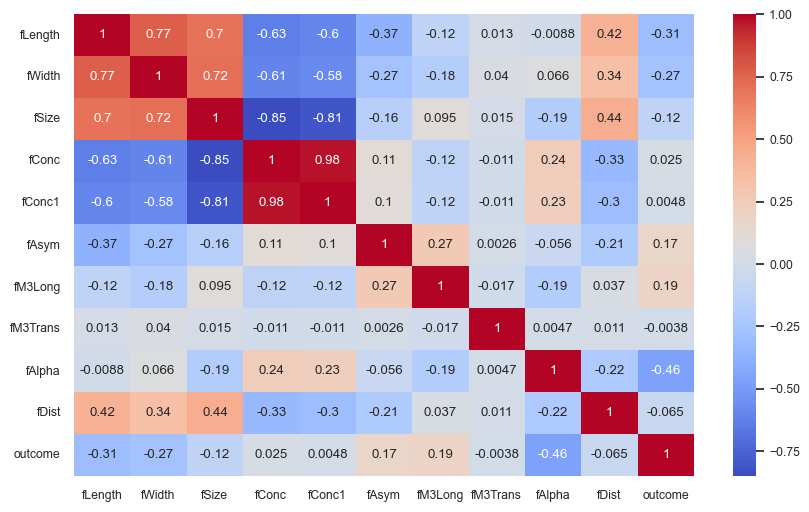

In [27]:
# Pearson's correlation (with heatmap and coolwarm color)
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(), annot=True, cmap="coolwarm");
plt.show()
# No strong linear correlation found

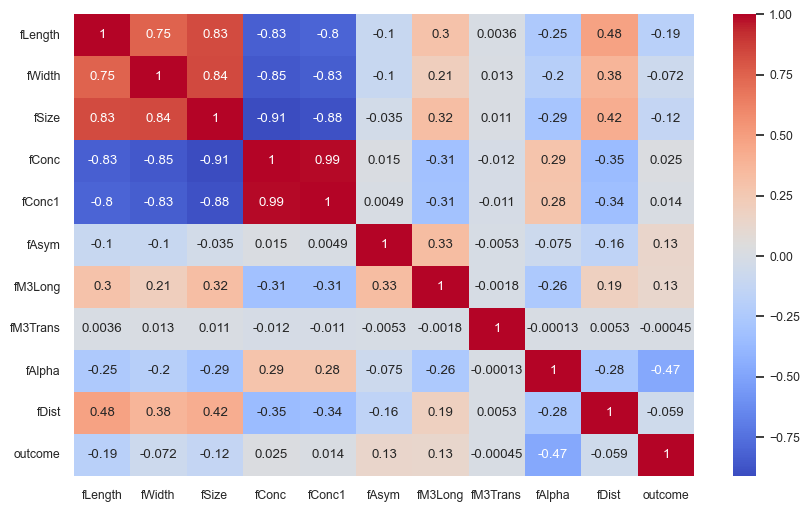

In [28]:
# Spearman's Rank or Spearman's Rho correlation
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="coolwarm"); # nonparametric correlation
plt.show()
# No strong linear correlation found

In [29]:
# Phi K correlations for all variables

! pip install phik
import phik
from phik import resources, report

In [30]:
df.phik_matrix()

interval columns not set, guessing: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'outcome']


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,outcome
fLength,1.000,0.743,0.718,0.709,0.687,0.788,0.819,0.646,0.408,0.568,0.471
fWidth,0.743,1.000,0.749,0.673,0.642,0.607,0.643,0.867,0.261,0.479,0.421
fSize,0.718,0.749,1.000,0.884,0.843,0.467,0.605,0.612,0.338,0.499,0.184
fConc,0.709,0.673,0.884,1.000,0.945,0.466,0.579,0.541,0.357,0.386,0.191
fConc1,0.687,0.642,0.843,0.945,1.000,0.453,0.561,0.525,0.344,0.372,0.182
fAsym,0.788,0.607,0.467,0.466,0.453,1.000,0.676,0.536,0.210,0.451,0.343
fM3Long,0.819,0.643,0.605,0.579,0.561,0.676,1.000,0.560,0.293,0.452,0.445
fM3Trans,0.646,0.867,0.612,0.541,0.525,0.536,0.560,1.000,0.190,0.390,0.369
fAlpha,0.408,0.261,0.338,0.357,0.344,0.210,0.293,0.190,1.000,0.328,0.613
fDist,0.568,0.479,0.499,0.386,0.372,0.451,0.452,0.390,0.328,1.000,0.164


In [31]:
from phik.report import plot_correlation_matrix
phik_overview = df.phik_matrix()

interval columns not set, guessing: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'outcome']


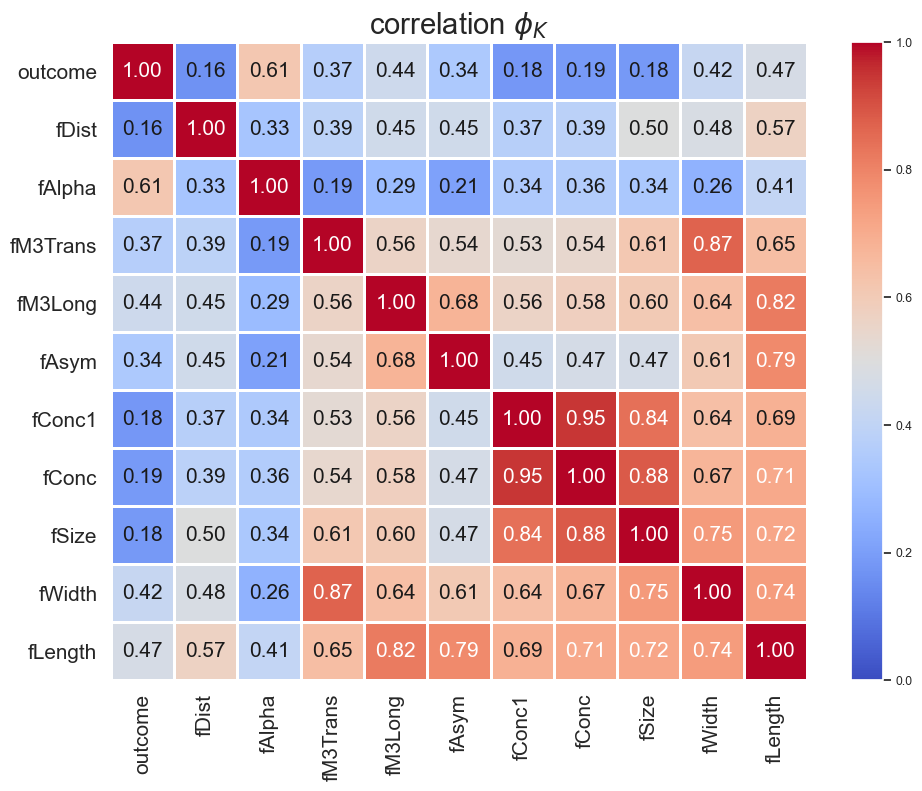

In [32]:
# Presenting Phi K data as a heatmap (credit: Jai Gupta, Stanford SPCS 2023)
plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="coolwarm", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1.5, 
                        figsize=(10, 8))
plt.tight_layout()
plt.show()

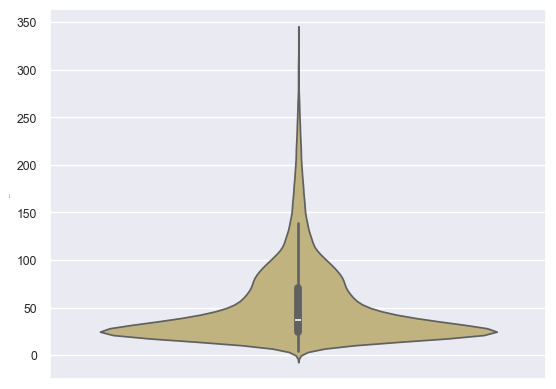

In [33]:
sns.violinplot(df['fLength'],color='y');
plt.show()

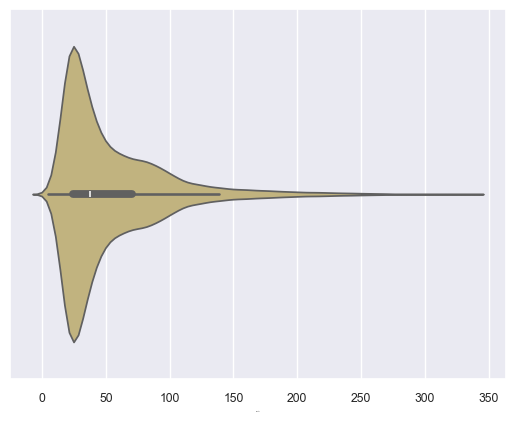

In [34]:
sns.violinplot(x=df['fLength'],color='y'); # Note inclusion of "x=" to rotate the plot
plt.show()

In [35]:
# From UT Austin Computer Science Department
# Use this function to create a combo boxplot and histogram for continuous (I/R --> int64 and float64) variables

def boxplot_histogram (feature, figsize=(10,7), bins = None):
    sns.set(font_scale=2) 
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2, 
                                           sharex = True,
                                           gridspec_kw = {"height_ratios": (.25, .75)}, 
                                           figsize = figsize 
                                           ) 
    sns.boxplot(feature, ax=ax_box2, orient = "h", showmeans=True, color='red') # mean value will be noted
    sns.distplot(feature, kde=F, ax=ax_hist2, bins=bins) if bins else sns.distplot(feature, kde=False, ax=ax_hist2, fit=norm)
    ax_hist2.axvline(np.mean(feature), color='g', linestyle='--') # Add mean to the histogram
    ax_hist2.axvline(np.median(feature), color='black', linestyle='-') # Add median to the histogram
    plt.axvline(feature.mode()[0], color='r', linestyle='dashed', linewidth=1); #Add mode to the histogram

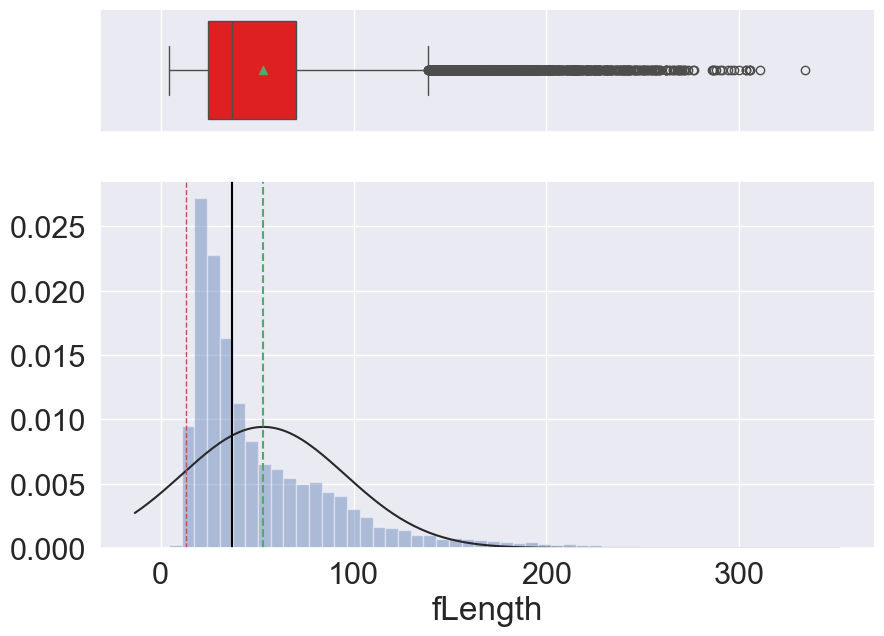

In [36]:
boxplot_histogram(df.fLength)
plt.show()

## Bivariate Analyses

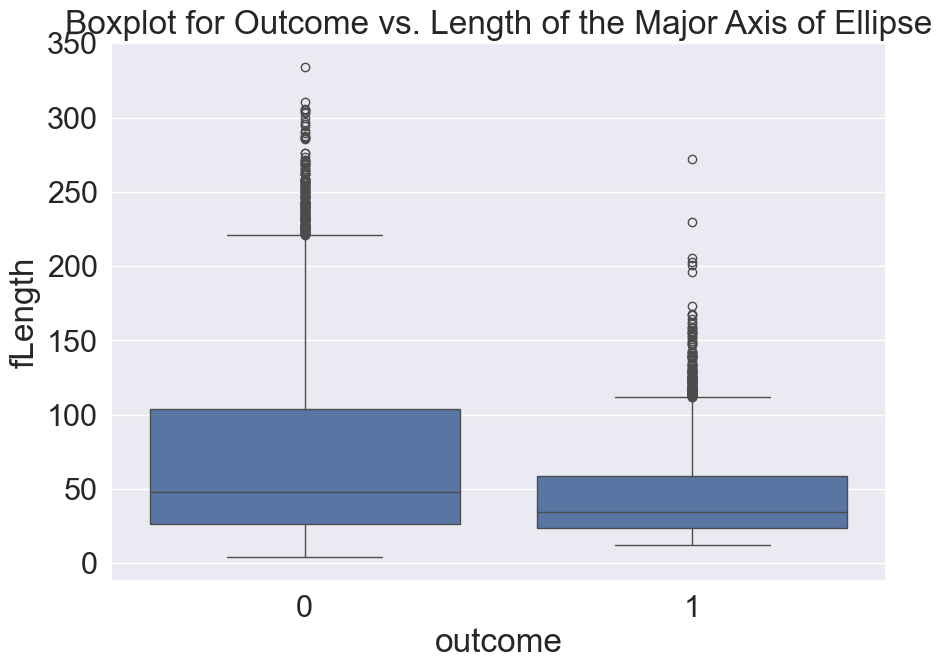

In [37]:
# Boxplot with DV and 1 IV
# sns.boxplot(x = "categorical_var", y = "numeric_var", data = df)
# plt.title('graph_title')
# plt.show()

plt.figure(figsize=(10,7))
sns.boxplot(x = "outcome", y = "fLength", data = df)
plt.title('Boxplot for Outcome vs. Length of the Major Axis of Ellipse')
plt.show()

##### Note: Outliers were not addressed because they did not significantly affect end results

# Supervised Machine Learning (Binary Classification)

In [38]:
# Make a copy of dataframe
data=df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  outcome   19020 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.6 MB


In [39]:
# Libraries for different ML classifiers

from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

# Libraries for model tuning and evaluation metrics
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

#### Decision Tree

In [40]:
# Separate Outcome or Target variable from the predictors

X = data.drop('outcome',axis=1)
y = data['outcome'].astype('int64')

# We used .astype ('int64) above to convert target to integers since some functions might not work with bool type

# Split the data into training and test sets

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=1)
print(X_train.shape, X_test.shape)

(13314, 10) (5706, 10)


## Initial Model Using the Decision Tree Classifier

In [41]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',class_weight={0:0.15,1:0.85},random_state=1)

# 2 commonly used splitting criteria are Gini impurity and information gain (entropy)
# Gini: measures the probability of misclassifying a randomly chosen element if it were randomly labeled
    # Would goal be to minimize or maximize the Gini impurity when making splits???
        # MINIMIZE
    
    
# Information Gain (Entropy): entropy measures impurity or uncertainty, while information gain quantifies reduction in entropy
    # Which do we want to minimize? Maximize?
        # MINIMIZE Entropy
        # MAXIMIZE Information Gain

In [42]:
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.15, 1: 0.85}, random_state=1)

In [43]:
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

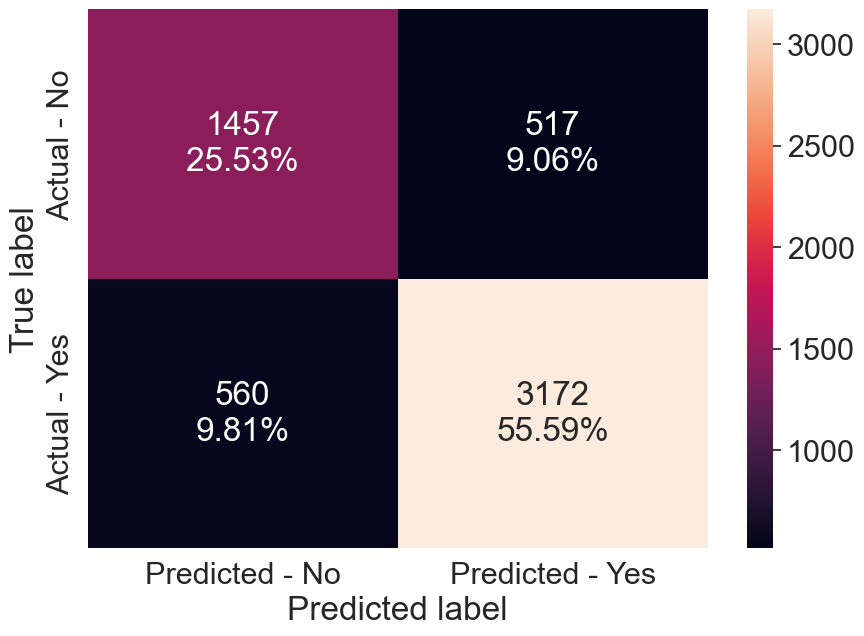

In [44]:
make_confusion_matrix(model,y_test)
plt.show()

In [45]:
y_train.value_counts(1)

outcome
1   0.646
0   0.354
Name: proportion, dtype: float64

In [46]:
column_names = list(data.columns)
column_names.remove('outcome')  # As this is the DV                
feature_names = column_names
print(feature_names)

['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']


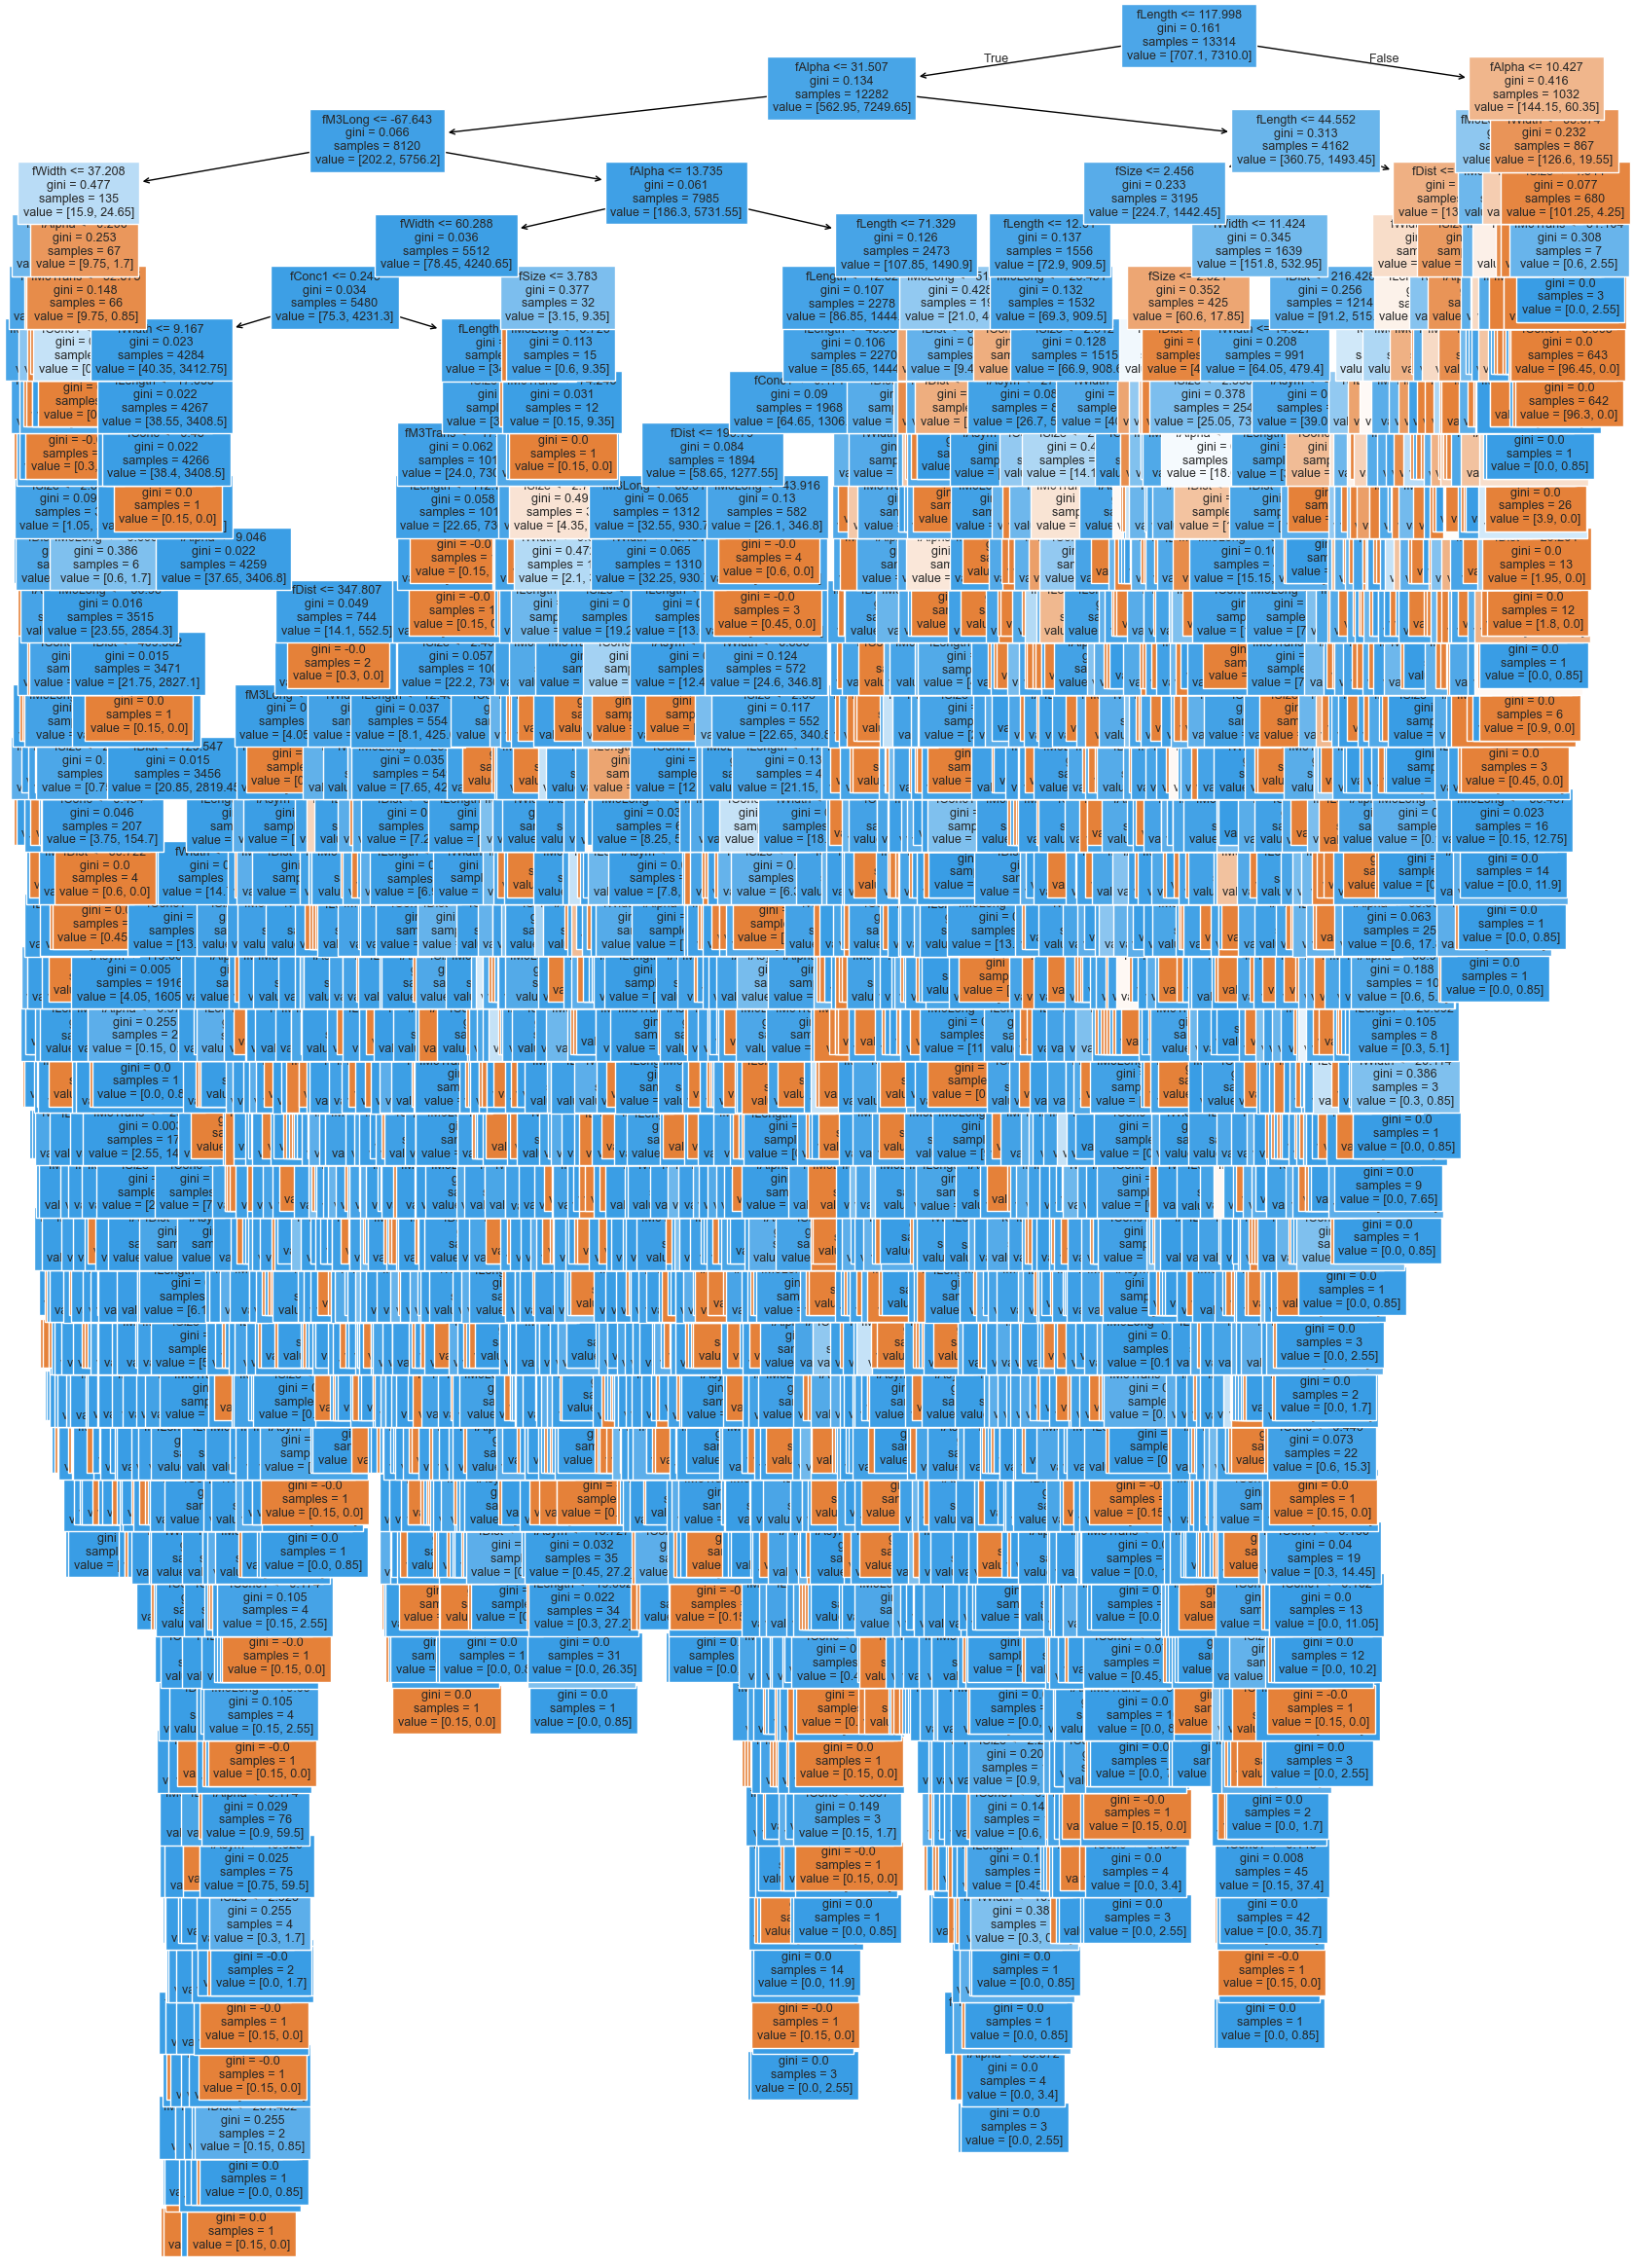

In [47]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics

plt.figure(figsize=(20,30))
out = tree.plot_tree(model,feature_names=feature_names,filled=True,fontsize=9,node_ids=False,class_names=None,)
# Code below will add arrows to the decision tree split if they are missing
for o in out:
     arrow = o.arrow_patch
     if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [48]:
# Text report showing the rules of the decision tree

print(tree.export_text(model,feature_names=feature_names,show_weights=True))

|--- fLength <= 118.00
|   |--- fAlpha <= 31.51
|   |   |--- fM3Long <= -67.64
|   |   |   |--- fWidth <= 37.21
|   |   |   |   |--- fAlpha <= 10.67
|   |   |   |   |   |--- fLength <= 70.92
|   |   |   |   |   |   |--- weights: [0.30, 0.00] class: 0
|   |   |   |   |   |--- fLength >  70.92
|   |   |   |   |   |   |--- fM3Long <= -112.06
|   |   |   |   |   |   |   |--- weights: [0.30, 0.00] class: 0
|   |   |   |   |   |   |--- fM3Long >  -112.06
|   |   |   |   |   |   |   |--- fM3Trans <= -27.33
|   |   |   |   |   |   |   |   |--- weights: [0.15, 0.00] class: 0
|   |   |   |   |   |   |   |--- fM3Trans >  -27.33
|   |   |   |   |   |   |   |   |--- fDist <= 61.82
|   |   |   |   |   |   |   |   |   |--- weights: [0.15, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- fDist >  61.82
|   |   |   |   |   |   |   |   |   |--- fSize <= 2.85
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 11.05] class: 1
|   |   |   |   |   |   |   |   |   |--- fSize >  2.85
|   |   |   

In [49]:
# Importance of features in the tree building (The importance of a feature is computed as the 
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance)

print (pd.DataFrame(model.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

           Imp
fLength  0.286
fAlpha   0.138
fWidth   0.130
fSize    0.117
fDist    0.072
fM3Long  0.072
fConc    0.048
fAsym    0.047
fM3Trans 0.047
fConc1   0.042


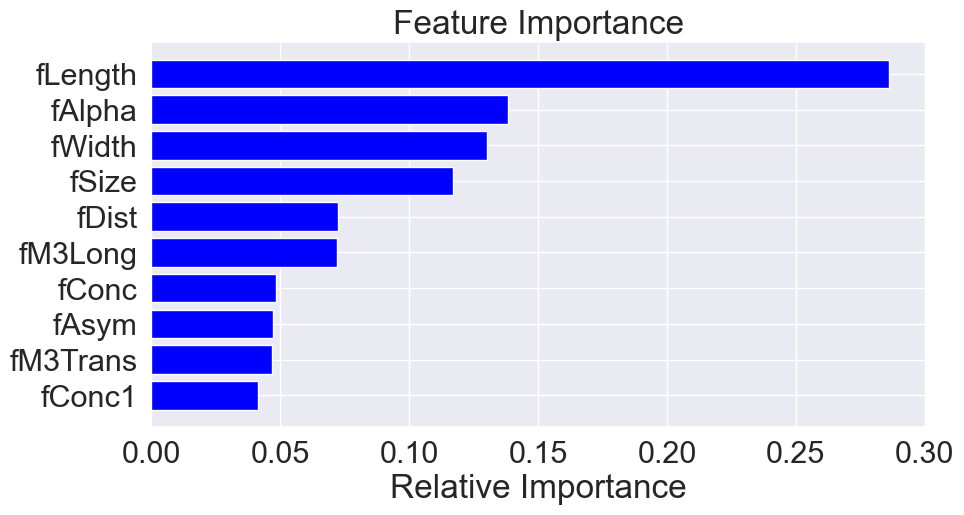

In [50]:
# Example of Feature Importance

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,5))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='blue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
# Choose the type of classifier
estimator = DecisionTreeClassifier(random_state=1,class_weight = {0:.15,1:.85}) 
# Random state = controls random shuffling and splitting
# Grid of parameters to choose from
parameters = {
            'max_depth': np.arange(15,27),
            'criterion': ['entropy','gini'],
            'splitter': ['best','random'],
            'min_impurity_decrease': [0.0001,0.001,0.001],
            'max_features': ['log2','sqrt']
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.15, 1: 0.85}, max_depth=15,
                       max_features='log2', min_impurity_decrease=0.001,
                       random_state=1, splitter='random')

In [53]:
make_confusion_matrix(estimator,y_test)

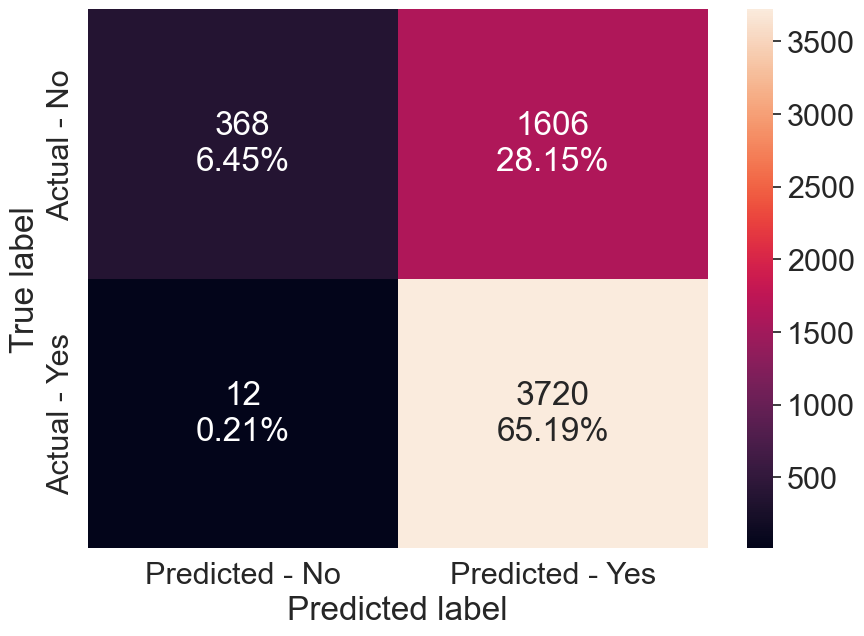

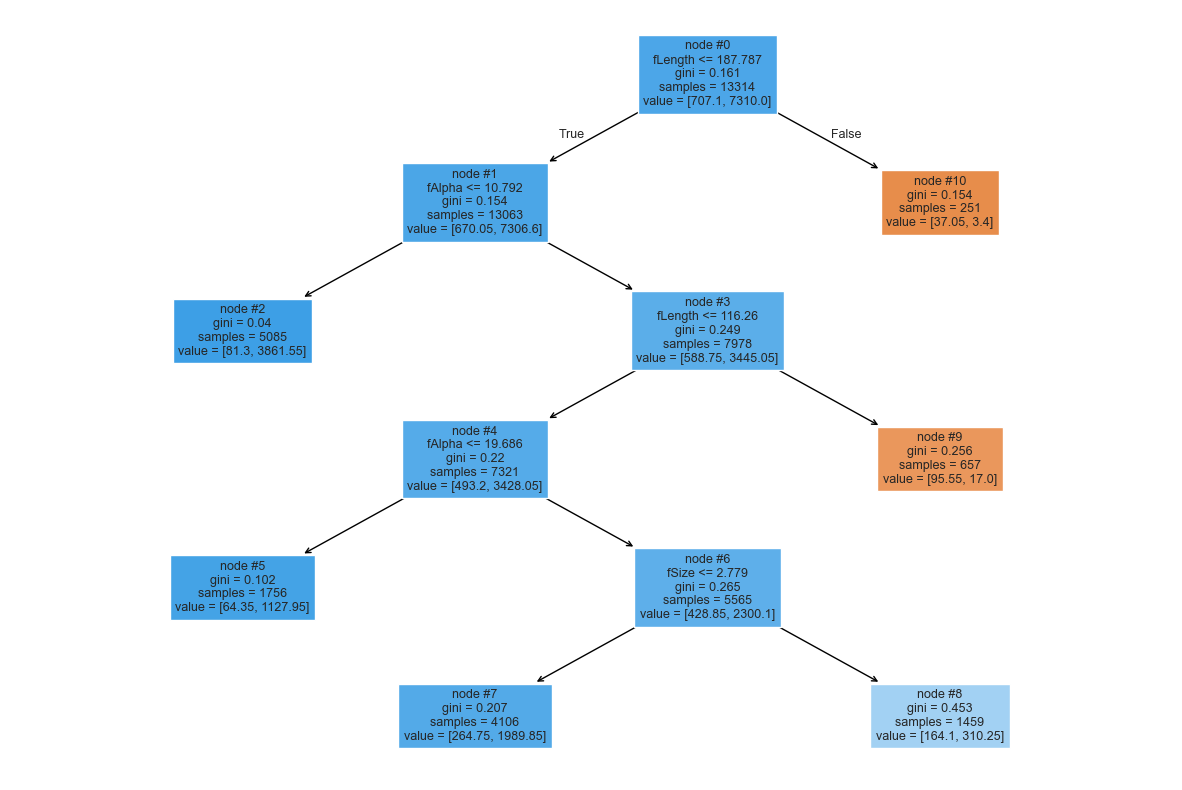

In [54]:
plt.figure(figsize=(15,10))
out = tree.plot_tree(estimator,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=None)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [55]:
print(tree.export_text(estimator,feature_names=feature_names,show_weights=False))

|--- fLength <= 187.79
|   |--- fAlpha <= 10.79
|   |   |--- class: 1
|   |--- fAlpha >  10.79
|   |   |--- fLength <= 116.26
|   |   |   |--- fAlpha <= 19.69
|   |   |   |   |--- class: 1
|   |   |   |--- fAlpha >  19.69
|   |   |   |   |--- fSize <= 2.78
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- fSize >  2.78
|   |   |   |   |   |--- class: 1
|   |   |--- fLength >  116.26
|   |   |   |--- class: 0
|--- fLength >  187.79
|   |--- class: 0



In [56]:
# Gini importance
print (pd.DataFrame(estimator.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

           Imp
fLength  0.584
fAlpha   0.276
fSize    0.140
fWidth   0.000
fConc    0.000
fConc1   0.000
fAsym    0.000
fM3Long  0.000
fM3Trans 0.000
fDist    0.000


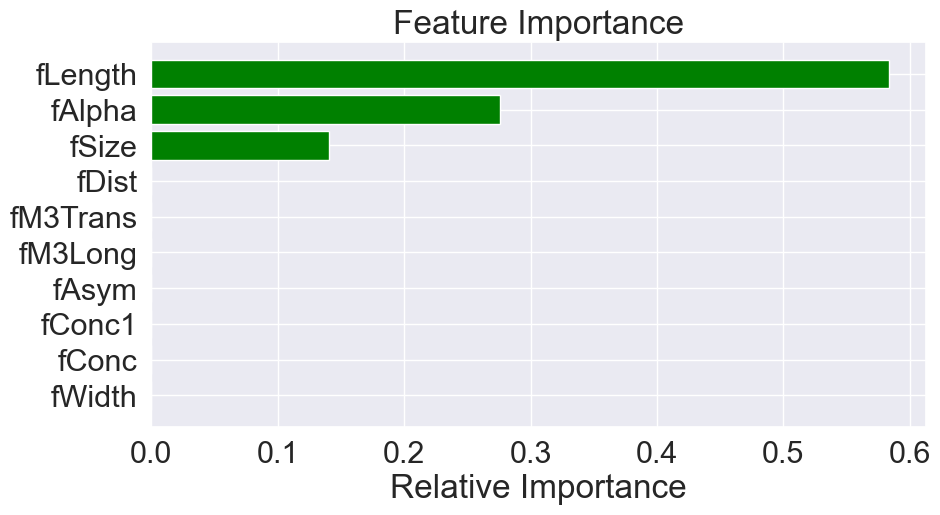

In [57]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,5))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Decision Tree

### Now let's  run and compare a Decision Tree (again, to demonstrate how we compare it with other models), a Bagging Classifier, and a Random Forest, along with the tuned versions of each.

#### 6 models total:
* Decision Tree
* Tuned Decision Tree
* Bagging Classifier
* Tuned Bagging Classfier
* Random Forest
* Tuned Random Forest
  

### Decision Tree

Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It works by recursively splitting the dataset into subsets based on feature values, aiming to create branches that lead to the most homogeneous (pure) groups regarding the target variable. Each internal node represents a decision rule on a feature, and each leaf node represents a class label (for classification) or a continuous value (for regression).

Decision Trees are easy to interpret, visualize, and understand. However, they can easily overfit the training data if not properly pruned or regularized.

In [58]:
dtree_estimator = DecisionTreeClassifier(class_weight={0:0.3,1:0.70},random_state=1)

dtree_estimator = DecisionTreeClassifier(random_state=1, class_weight={0: 0.3, 1: 0.7})
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, random_state=1)

In [59]:
#  Function to calculate different metric scores - Accuracy, Recall, Preceision, and F1 Scores

def get_metrics_score(model,flag=True):
    # defining an empty list to store train and test results
    score_list=[] 
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    # Recall = minimizes false negatives
    
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    # Precision = minimizes false positives

    train_f1 = metrics.f1_score(y_train,pred_train)
    test_f1 = metrics.f1_score(y_test,pred_test)
    # F1 Score = balances precision and recall
    
    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))
        
    if flag == True: 
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))
        print("F1 Score on training set : ",metrics.f1_score(y_train,pred_train))
        print("F1 Score on test set : ",metrics.f1_score(y_test,pred_test))
    
    return score_list # returns the list with train and test scores

In [60]:
# Function to make confusion matrix

def make_confusion_matrix(model, y_actual, labels=[1, 0]):
    # Predict using the model
    y_predict = model.predict(X_test)  # <- This should match y_actual's source
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=[0, 1])
    
    # Create a labeled DataFrame for the confusion matrix
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                              columns = [i for i in ['Predicted - No','Predicted - Yes']])
    
    # Format counts and percentages for annotation
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    # Combine into annotation labels
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    # Plot the heatmap
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Accuracy on training set :  1.0
Accuracy on test set :  0.8156326673676831
Recall on training set :  1.0
Recall on test set :  0.8612004287245445
Precision on training set :  1.0
Precision on test set :  0.8575240128068303
F1 Score on training set :  1.0
F1 Score on test set :  0.8593582887700535


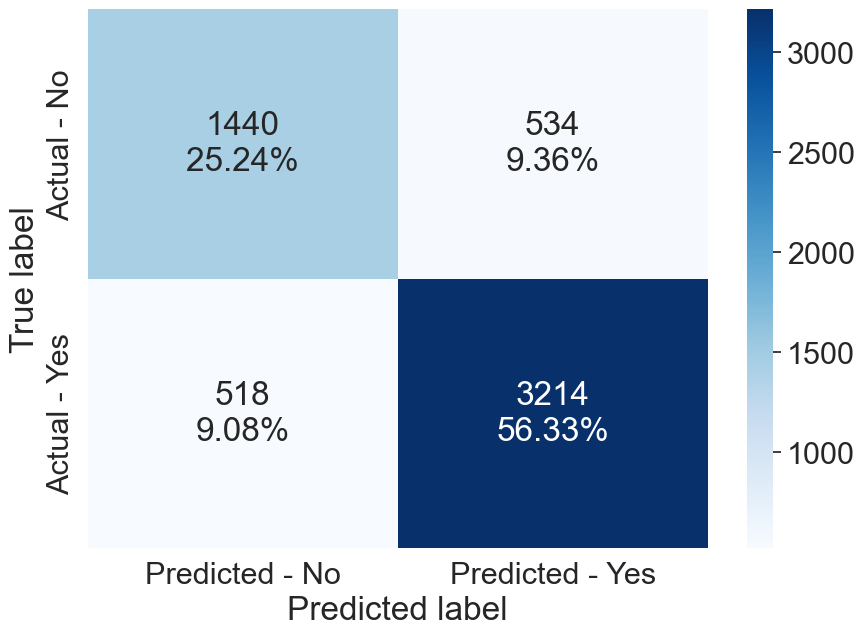

In [61]:
# Calculate metrics for your model
get_metrics_score(dtree_estimator)

# Create confusion matrix for your mdodel
make_confusion_matrix(dtree_estimator, y_test)

### Tuned Decision Tree

In [62]:
dtree_tuned = DecisionTreeClassifier(class_weight={0:0.35, 1:0.65}, random_state=1)

parameters = {
    'max_depth': np.arange(2, 10),
    'min_samples_leaf': [5, 7, 10, 15],
    'max_leaf_nodes': [2, 3, 5, 10, 15],
    'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
}

# Parameters above control the size and shape of the tree, preventing it from growing too large or fitting noise.

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=scorer, n_jobs=-1)
grid_obj.fit(X_train, y_train)

dtree_tuned = grid_obj.best_estimator_

dtree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.35, 1: 0.65}, max_depth=2,
                       max_leaf_nodes=2, min_impurity_decrease=0.0001,
                       min_samples_leaf=5, random_state=1)

Accuracy on training set :  0.6459366080817185
Accuracy on test set :  0.6540483701366983
Recall on training set :  1.0
Recall on test set :  1.0
Precision on training set :  0.6459366080817185
Precision on test set :  0.6540483701366983
F1 Score on training set :  0.7848863740074838
F1 Score on test set :  0.7908455181182454


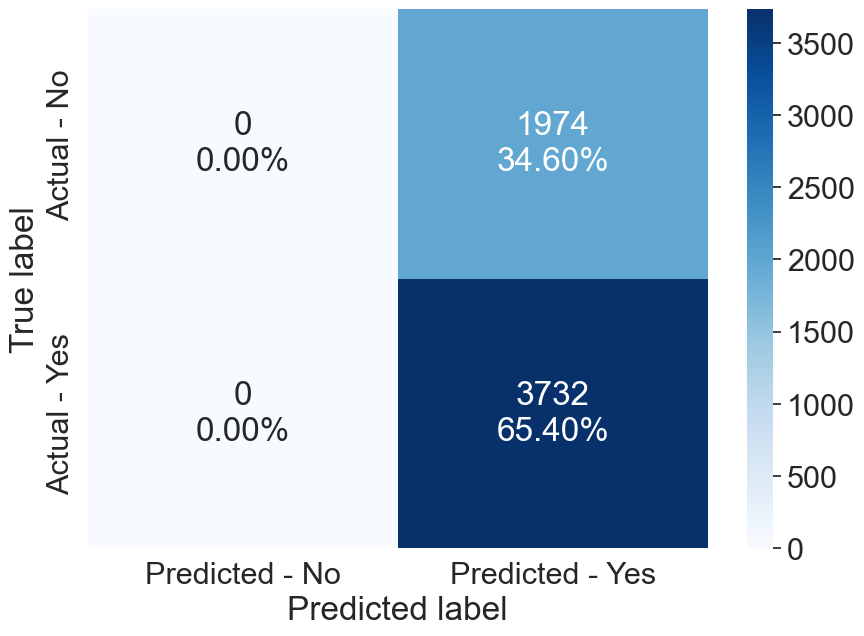

In [63]:
get_metrics_score(dtree_tuned)
make_confusion_matrix(dtree_tuned,y_test)

### Bagging Classifier:

The BaggingClassifier (Bootstrap Aggregating) is an ensemble meta-estimator that fits base classifiers on random subsets of the original dataset (with replacement) and aggregates their predictions to improve overall model stability and accuracy. By combining multiple models trained on different bootstrap samples, bagging helps reduce variance and overfitting compared to a single estimator.

It is particularly effective with high-variance, low-bias models like decision trees.

Accuracy on training set :  0.9939161784587652
Accuracy on test set :  0.8624255169996495
Recall on training set :  0.9955813953488372
Recall on test set :  0.9056806002143623
Precision on training set :  0.9950029052876235
Precision on test set :  0.8864411224757409
F1 Score on training set :  0.9952920662598082
F1 Score on test set :  0.8959575878064944


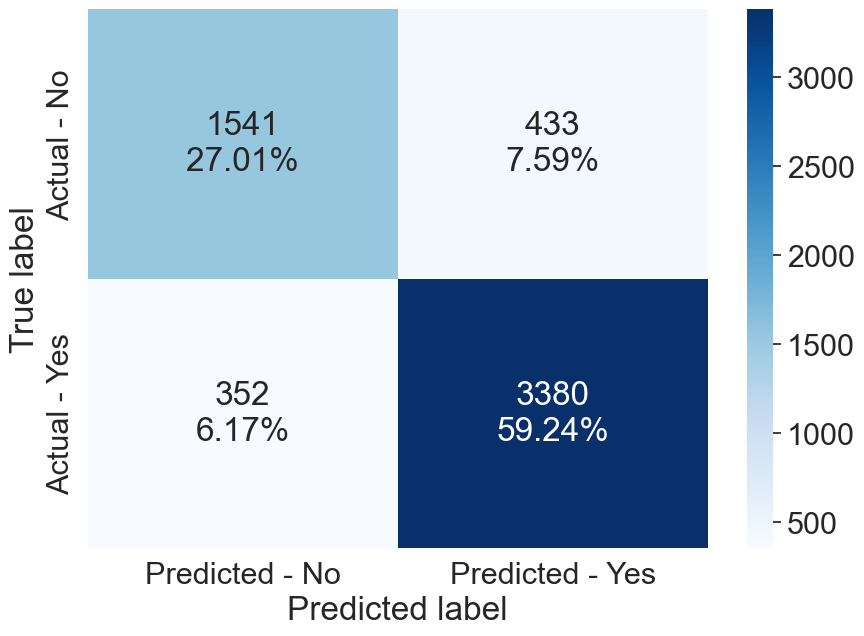

In [64]:
# Fit the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train,y_train)

# Calculate metrics
get_metrics_score(bagging_classifier)

# Create the confusion matrix
make_confusion_matrix(bagging_classifier,y_test)

### Tuned Bagging Classifier:

In [65]:
# Define base BaggingClassifier
bagging_tuned = BaggingClassifier(random_state=1)

# Hyperparameter grid
parameters = {
    'max_samples': [0.7, 0.8, 0.9, 1],
    'max_features': [0.7, 0.8, 0.9, 1],
    'n_estimators': [10, 20, 30, 40, 50],
}

# Use recall as scoring metric
recall_scorer = metrics.make_scorer(metrics.recall_score)

# Setup GridSearchCV with parallel jobs and 5-fold CV
grid_obj = GridSearchCV(bagging_tuned, parameters, scoring=recall_scorer, cv=5, n_jobs=-1)

# Fit grid search
grid_obj.fit(X_train, y_train)

# Best estimator from grid search
bagging_tuned = grid_obj.best_estimator_

# Fit the best model on full training data
bagging_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=1, random_state=1)

Accuracy on training set :  0.6459366080817185
Accuracy on test set :  0.6540483701366983
Recall on training set :  1.0
Recall on test set :  1.0
Precision on training set :  0.6459366080817185
Precision on test set :  0.6540483701366983
F1 Score on training set :  0.7848863740074838
F1 Score on test set :  0.7908455181182454


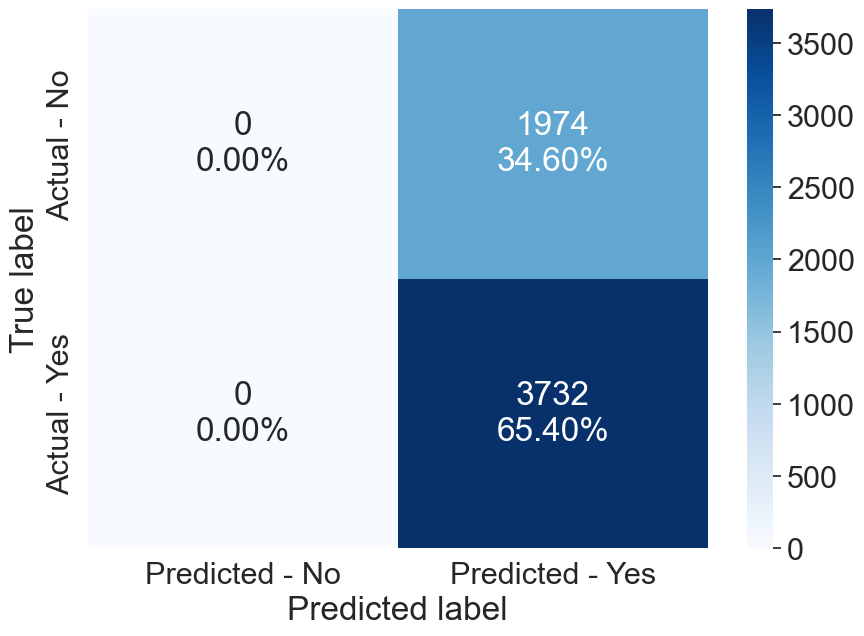

In [66]:
get_metrics_score(bagging_tuned)

make_confusion_matrix(bagging_tuned,y_test)

### Random Forest

Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It introduces randomness by selecting random subsets of features and data samples to build each tree, which helps reduce overfitting and improves generalization.

Because it aggregates many decision trees, Random Forest tends to be robust, accurate, and resistant to noise and outliers, making it one of the most popular machine learning algorithms for classification and regression tasks.

Accuracy on training set :  1.0
Accuracy on test set :  0.8746933052926744
Recall on training set :  1.0
Recall on test set :  0.9356913183279743
Precision on training set :  1.0
Precision on test set :  0.8802621628434585
F1 Score on training set :  1.0
F1 Score on test set :  0.9071307962072996


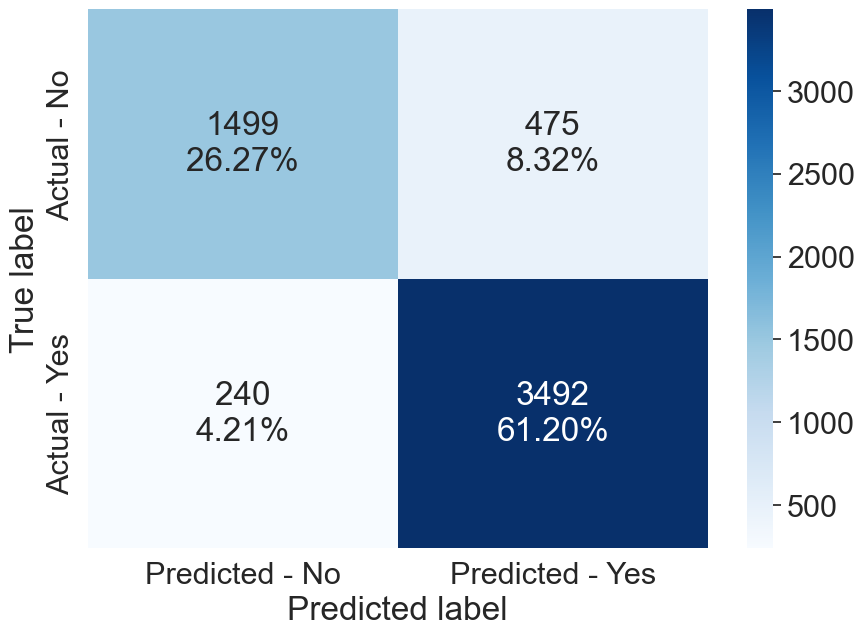

In [67]:
# Fit the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

# Calculate metrics
get_metrics_score(rf_estimator)

# Create the confusion matrix
make_confusion_matrix(rf_estimator,y_test)

### Tuned Random Forest

In [68]:
%%time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

rf_tuned = RandomForestClassifier(class_weight={0:0.35,1:0.65}, random_state=1)

parameters = {  
    'max_depth': list(np.arange(3, 10, 1)),
    'max_features': np.arange(0.6, 1.1, 0.1),
    'min_samples_split': np.arange(2, 20, 5),
    'n_estimators': np.arange(30, 160, 20),
    'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
}

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs=-1)
grid_obj.fit(X_train, y_train)

rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)

CPU times: user 20.5 s, sys: 11.6 s, total: 32.1 s
Wall time: 1h 24min 9s


RandomForestClassifier(class_weight={0: 0.35, 1: 0.65}, max_depth=3,
                       max_features=0.6, min_impurity_decrease=0.1,
                       n_estimators=30, random_state=1)

Accuracy on training set :  0.6459366080817185
Accuracy on test set :  0.6540483701366983
Recall on training set :  1.0
Recall on test set :  1.0
Precision on training set :  0.6459366080817185
Precision on test set :  0.6540483701366983
F1 Score on training set :  0.7848863740074838
F1 Score on test set :  0.7908455181182454


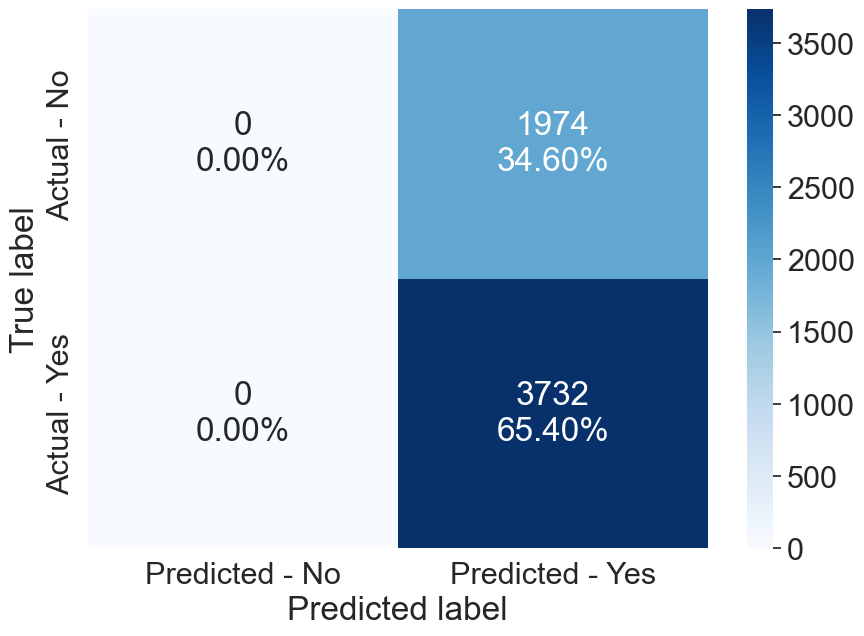

In [69]:
#Calculating different metrics
get_metrics_score(rf_tuned)

#Creating confusion matrix
make_confusion_matrix(rf_tuned,y_test)

### Comparing Supervised ML Classification Models

In [70]:
# Identify the models to compare
models = [dtree_estimator, dtree_tuned, bagging_classifier, bagging_tuned, rf_estimator, rf_tuned]

# Define empty lists to store results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []
f1_train = []
f1_test = []

# Loop through all models to collect metrics (Accuracy, Recall, Precision, F1)
for model in models:
    scores = get_metrics_score(model, False)
    acc_train.append(scores[0])
    acc_test.append(scores[1])
    recall_train.append(scores[2])
    recall_test.append(scores[3])
    precision_train.append(scores[4])
    precision_test.append(scores[5])
    f1_train.append(scores[6])
    f1_test.append(scores[7])

In [71]:
# Compare models on evaluation metrics

comparison_frame = pd.DataFrame({
    'Model': ['Decision Tree', 'Tuned Decision Tree', 'Bagging Classifier', 'Tuned Bagging Classifier', 'Random Forest', 'Tuned Random Forest'],
    'Train_Accuracy': acc_train,
    'Test_Accuracy': acc_test,
    'Train_Recall': recall_train,
    'Test_Recall': recall_test,
    'Train_Precision': precision_train,
    'Test_Precision': precision_test,
    'Train_F1': f1_train,
    'Test_F1': f1_test
})

# Sort models in decreasing order of most important metric
comparison_frame_sorted = comparison_frame.sort_values(by='Test_F1', ascending=False)

# Set display options to avoid wrapping wide DataFrames
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# Print sorted DataFrame
print(comparison_frame_sorted)

                      Model  Train_Accuracy  Test_Accuracy  Train_Recall  Test_Recall  Train_Precision  Test_Precision  Train_F1  Test_F1
4             Random Forest           1.000          0.875         1.000        0.936            1.000           0.880     1.000    0.907
2        Bagging Classifier           0.994          0.862         0.996        0.906            0.995           0.886     0.995    0.896
0             Decision Tree           1.000          0.816         1.000        0.861            1.000           0.858     1.000    0.859
1       Tuned Decision Tree           0.646          0.654         1.000        1.000            0.646           0.654     0.785    0.791
3  Tuned Bagging Classifier           0.646          0.654         1.000        1.000            0.646           0.654     0.785    0.791
5       Tuned Random Forest           0.646          0.654         1.000        1.000            0.646           0.654     0.785    0.791


### Logistic Regression

In [72]:
# Import additional library
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [73]:
# Standardize the features before running logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the logistic regression model
log_reg = LogisticRegression(
    solver='newton-cg',
    max_iter=1000,
    penalty=None,           # Regularization
    verbose=True,           # Shows optimization progress
    n_jobs=-1,              # Use all CPU cores
    random_state=0
)

In [74]:
def get_metrics_score(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [75]:
# Fit the model to the training data
log_reg.fit(X_train_scaled, y_train)

# Predict probabilities for ROC curve
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


In [76]:
def get_metrics_score(model, X_train, y_train, X_test, y_test):
    # Predict on train and test
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Print results
    print("Model Performance")
    print("-" * 40)
    print("{:<15} {:<10} {:<10}".format("Metric", "Train", "Test"))
    print("-" * 40)
    print("{:<15} {:<10.2f} {:<10.2f}".format("Accuracy", 
          accuracy_score(y_train, y_pred_train), accuracy_score(y_test, y_pred_test)))
    print("{:<15} {:<10.2f} {:<10.2f}".format("Precision", 
          precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)))
    print("{:<15} {:<10.2f} {:<10.2f}".format("Recall", 
          recall_score(y_train, y_pred_train), recall_score(y_test, y_pred_test)))
    print("{:<15} {:<10.2f} {:<10.2f}".format("F1 Score", 
          f1_score(y_train, y_pred_train), f1_score(y_test, y_pred_test)))
    print("-" * 40)

In [77]:
def make_confusion_matrix(model, X_test, y_actual, labels=[0, 1]):
    # Predict using the model
    y_predict = model.predict(X_test)
    
    # Compute confusion matrix
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=labels)
    
    # Create labeled DataFrame
    df_cm = pd.DataFrame(
        cm,
        index=["Actual - No", "Actual - Yes"],
        columns=["Predicted - No", "Predicted - Yes"]
    )
    
    # Prepare annotation labels (counts + percentages)
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    annot_labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    annot_labels = np.asarray(annot_labels).reshape(cm.shape)
    
    # Plot the heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_cm, annot=annot_labels, fmt="", cmap="Blues")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("")
    plt.tight_layout()
    plt.show()

Model Performance
----------------------------------------
Metric          Train      Test      
----------------------------------------
Accuracy        0.79       0.79      
Precision       0.80       0.80      
Recall          0.90       0.90      
F1 Score        0.85       0.85      
----------------------------------------


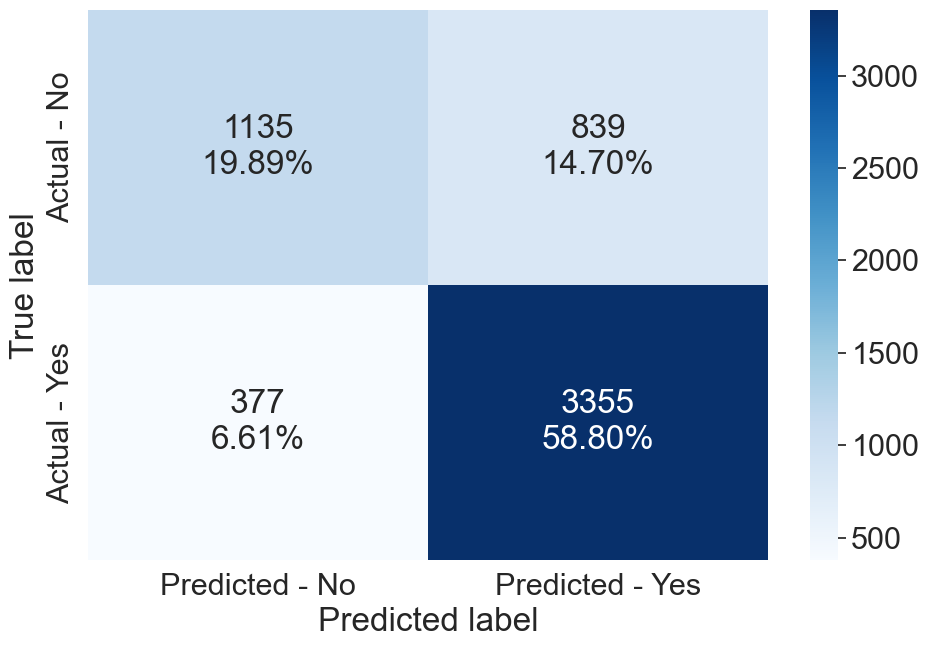

In [78]:
get_metrics_score(log_reg, X_train_scaled, y_train, X_test_scaled, y_test)
make_confusion_matrix(log_reg, X_test_scaled, y_test)

### ROC Curve

The ROC Curve, or Receiver Operating Characteristic Curve, is a visual tool used to evaluate how well a binary classification model (like logistic regression) performs. It shows the trade-off between two things:

* **True Positive Rate (TPR)**: also called sensitivity or recall: the proportion of actual positives that the model correctly predicts as positive.

* **False Positive Rate (FPR)**: the proportion of actual negatives that the model incorrectly predicts as positive.

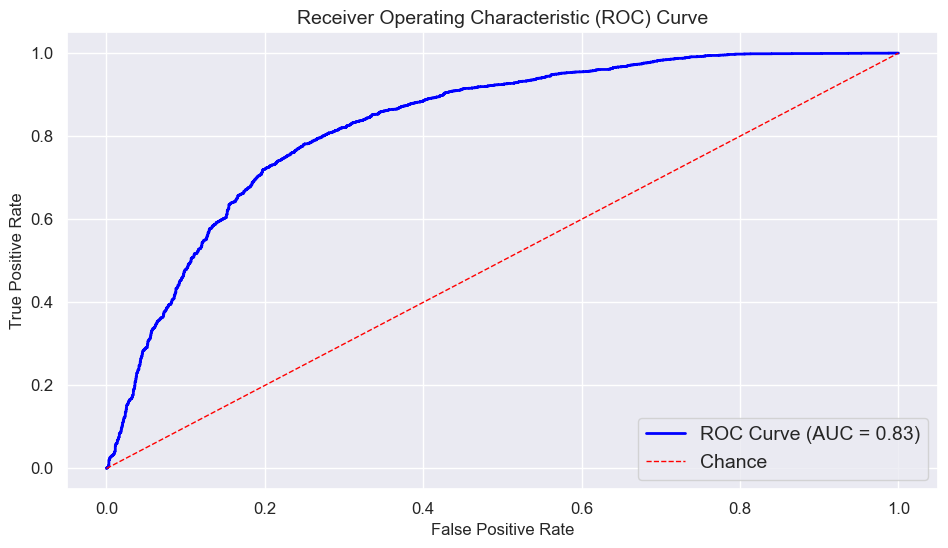

In [79]:
# Import additional library
from sklearn.metrics import roc_curve, auc

# Ensure X_test is scaled like training data
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Chance')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.legend(loc='lower right', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

### Boosting Algorithms

In [80]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n Performance: {name}")
    print("-" * 50)

    # Predict on train and test sets
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Compute metrics
    train_metrics = {
        'Accuracy': accuracy_score(y_train, y_pred_train),
        'Precision': precision_score(y_train, y_pred_train),
        'Recall': recall_score(y_train, y_pred_train),
        'F1 Score': f1_score(y_train, y_pred_train)
    }

    test_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1 Score': f1_score(y_test, y_pred_test)
    }

    # Print table-style output
    print("{:<12} {:<10} {:<10}".format("Metric", "Train", "Test"))
    print("-" * 32)
    for metric in train_metrics:
        print("{:<12} {:<10.2f} {:<10.2f}".format(
            metric, train_metrics[metric], test_metrics[metric]
        ))

    # Confusion Matrix (Test Set Only)
    cm = confusion_matrix(y_test, y_pred_test)
    total = cm.sum()
    labels = [f"{v}\n{v/total:.2%}" for v in cm.flatten()]
    labels = np.array(labels).reshape(cm.shape)

    df_cm = pd.DataFrame(cm,
                         index=["Actual - No", "Actual - Yes"],
                         columns=["Predicted - No", "Predicted - Yes"])

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Purples', cbar=False)
    plt.title("")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

### XGBoost

In [81]:
!pip install xgboost

from xgboost import XGBClassifier


 Performance: XGBoost (Default)
--------------------------------------------------
Metric       Train      Test      
--------------------------------
Accuracy     0.97       0.88      
Precision    0.96       0.88      
Recall       1.00       0.94      
F1 Score     0.98       0.91      


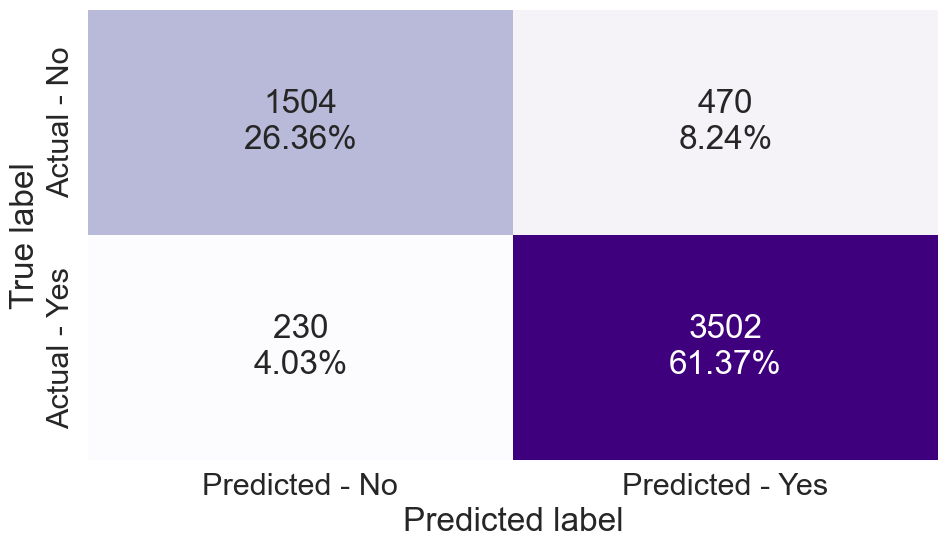

In [82]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=0
)
xgb.fit(X_train, y_train)
evaluate_model("XGBoost (Default)", xgb, X_train, y_train, X_test, y_test)

### Tuned XGBoost


 Performance: XGBoost (Tuned)
--------------------------------------------------
Metric       Train      Test      
--------------------------------
Accuracy     0.90       0.88      
Precision    0.89       0.88      
Recall       0.96       0.95      
F1 Score     0.93       0.91      


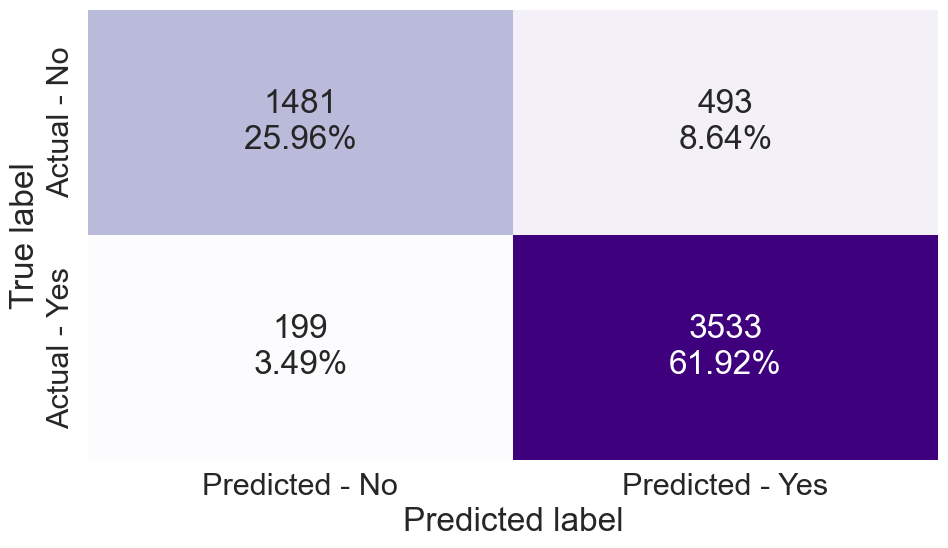

In [83]:
tuned_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=0
)
tuned_xgb.fit(X_train, y_train)
evaluate_model("XGBoost (Tuned)", tuned_xgb, X_train, y_train, X_test, y_test)

### Expanded comparison table

In [84]:
# Identify all models to compare
models = [
    dtree_estimator,
    dtree_tuned,
    bagging_classifier,
    bagging_tuned,
    rf_estimator,
    rf_tuned,
    log_reg,
    xgb,
    tuned_xgb
]

In [85]:
# List of model names (must match order of models above)
model_names = [
    'Decision Tree',
    'Tuned Decision Tree',
    'Bagging Classifier',
    'Tuned Bagging Classifier',
    'Random Forest',
    'Tuned Random Forest',
    'Logistic Regression',
    'XGBoost',
    'Tuned XGBoost'
]

In [86]:
# Clear the lists
acc_train, acc_test = [], []
recall_train, recall_test = [], []
precision_train, precision_test = [], []
f1_train, f1_test = [], []
final_model_names = []

In [87]:
def get_metrics_score(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    recall_train = recall_score(y_train, y_pred_train)
    recall_test = recall_score(y_test, y_pred_test)

    precision_train = precision_score(y_train, y_pred_train)
    precision_test = precision_score(y_test, y_pred_test)

    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)

    return [
        acc_train, acc_test,
        recall_train, recall_test,
        precision_train, precision_test,
        f1_train, f1_test
    ]

In [88]:
model_data_map = {
    "Logistic Regression": (X_train_scaled, X_test_scaled),
    "Support Vector Machine": (X_train_scaled, X_test_scaled),
    # others use unscaled
}

In [89]:
# Initialize this too!
final_model_names = []

for model, name in zip(models, model_names):
    if model is None:
        continue

    # Use scaled data if defined for that model
    X_tr, X_te = model_data_map.get(name, (X_train, X_test))

    scores = get_metrics_score(model, X_tr, y_train, X_te, y_test)

    acc_train.append(scores[0])
    acc_test.append(scores[1])
    recall_train.append(scores[2])
    recall_test.append(scores[3])
    precision_train.append(scores[4])
    precision_test.append(scores[5])
    f1_train.append(scores[6])
    f1_test.append(scores[7])
    final_model_names.append(name)

In [90]:
	
print("Lengths:", len(final_model_names), len(acc_train), len(acc_test), len(f1_test))

Lengths: 9 9 9 9


In [91]:
comparison_frame = pd.DataFrame({
    'Model': final_model_names,
    'Train_Accuracy': acc_train,
    'Test_Accuracy': acc_test,
    'Train_Recall': recall_train,
    'Test_Recall': recall_test,
    'Train_Precision': precision_train,
    'Test_Precision': precision_test,
    'Train_F1': f1_train,
    'Test_F1': f1_test
})

comparison_frame_sorted = comparison_frame.sort_values(by='Test_F1', ascending=False) # Sort by most important metric

# Display the table
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
print(comparison_frame_sorted)

                      Model  Train_Accuracy  Test_Accuracy  Train_Recall  Test_Recall  Train_Precision  Test_Precision  Train_F1  Test_F1
8             Tuned XGBoost           0.903          0.879         0.964        0.947            0.894           0.878     0.928    0.911
7                   XGBoost           0.974          0.877         0.995        0.938            0.965           0.882     0.980    0.909
4             Random Forest           1.000          0.875         1.000        0.936            1.000           0.880     1.000    0.907
2        Bagging Classifier           0.994          0.862         0.996        0.906            0.995           0.886     0.995    0.896
0             Decision Tree           1.000          0.816         1.000        0.861            1.000           0.858     1.000    0.859
6       Logistic Regression           0.793          0.787         0.899        0.899            0.804           0.800     0.849    0.847
1       Tuned Decision Tree       

### Feature Importance for Best Model

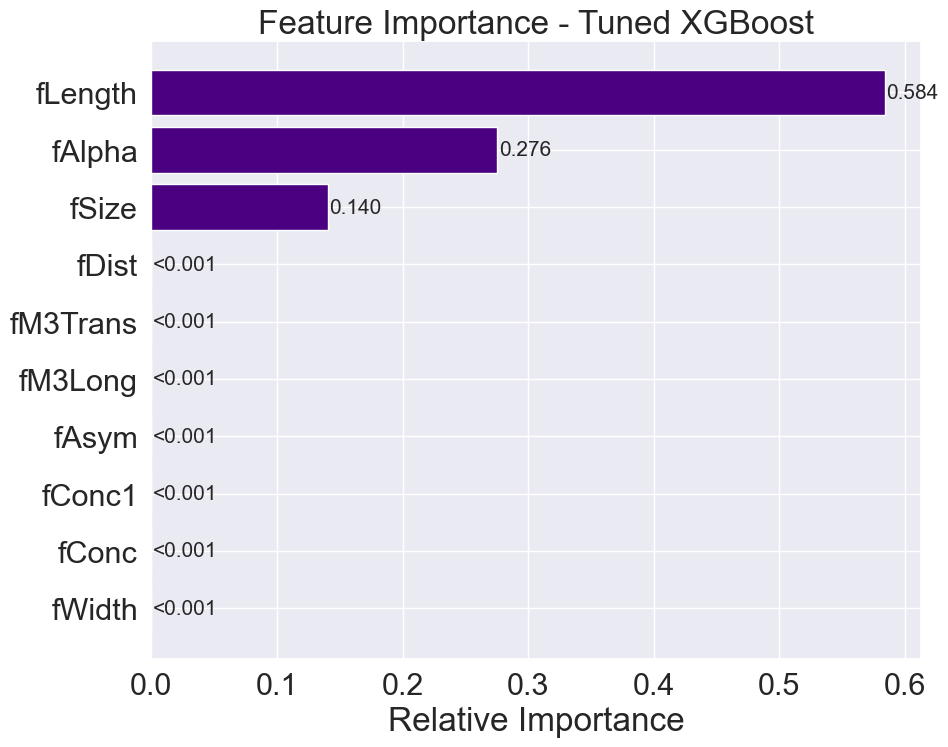

In [92]:
# Get feature names and their importance scores for the best model

model_name = 'Tuned XGBoost'  # dynamically assign this as needed

plt.figure(figsize=(10, 8))
plt.title(f'Feature Importance - {model_name}')
plt.barh(range(len(indices)), importances[indices], color='indigo', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')

for i, idx in enumerate(indices):
    val = importances[idx]
    if val < 0.001:
        label = "<0.001"
    else:
        label = f"{val:.3f}"
    plt.text(val + 0.001, i, label, va='center', fontsize=15)

plt.tight_layout()
plt.show()